In [80]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split 
import warnings 
warnings.filterwarnings("ignore")

In [81]:
sns.get_dataset_names() 

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [82]:
data = sns.load_dataset('mpg')

In [83]:
data.head() 

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [84]:
data.shape

(398, 9)

In [85]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [86]:
data.nunique()  

mpg             129
cylinders         5
displacement     82
horsepower       93
weight          351
acceleration     95
model_year       13
origin            3
name            305
dtype: int64

In [87]:
data.nunique() 

mpg             129
cylinders         5
displacement     82
horsepower       93
weight          351
acceleration     95
model_year       13
origin            3
name            305
dtype: int64

In [88]:
data.horsepower.unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [89]:
data.isnull().sum() 

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [90]:
data.duplicated().sum() 

0

In [91]:
df = data.copy() 

In [92]:
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

In [93]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,398.0,104.304020,38.222625,46.0,76.000,93.5,125.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


In [94]:
numerical = df.select_dtypes(include=['int','float']).columns 
categorical = df.select_dtypes(include=['object']).columns 
 
print(numerical) 
print(categorical) 

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year'],
      dtype='object')
Index(['origin', 'name'], dtype='object')


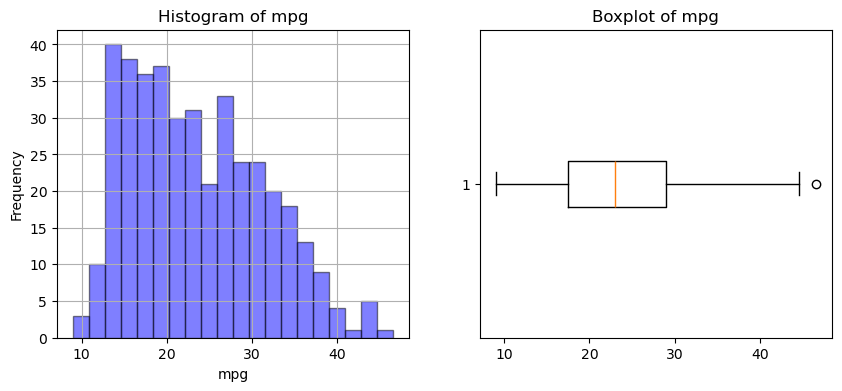

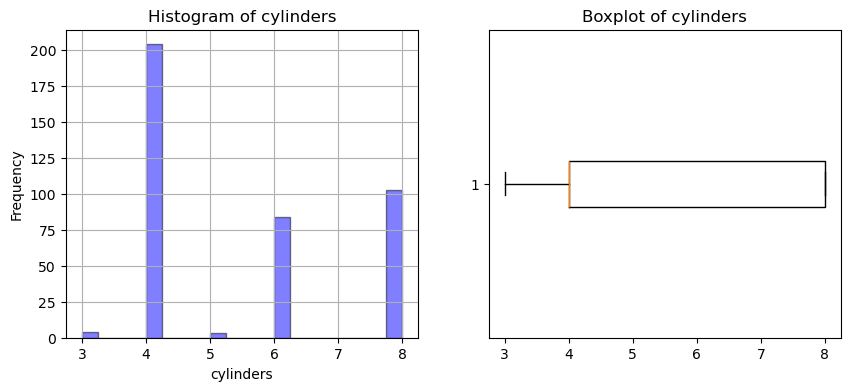

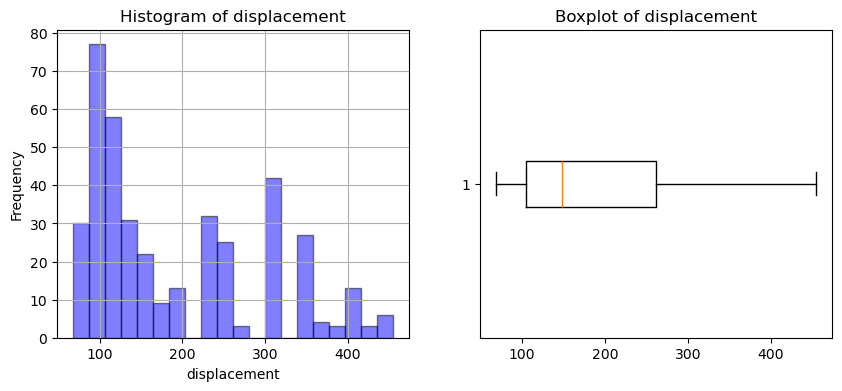

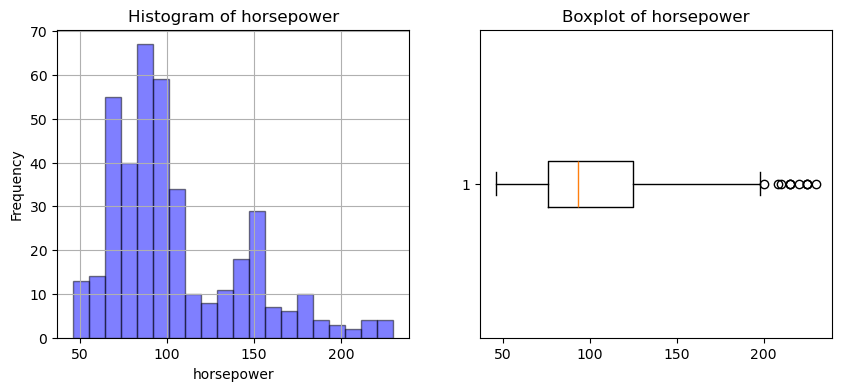

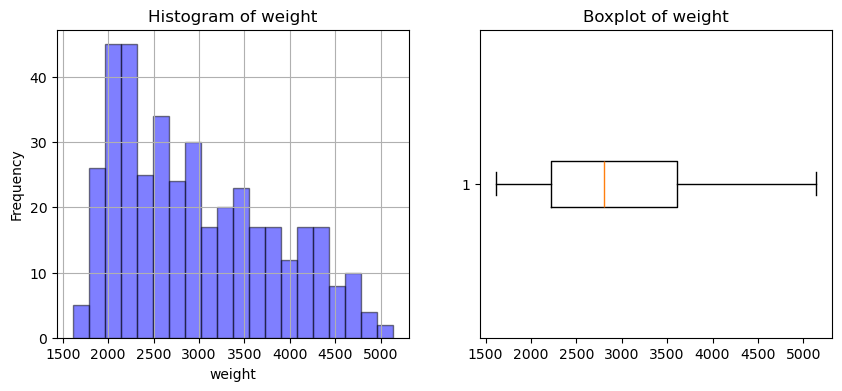

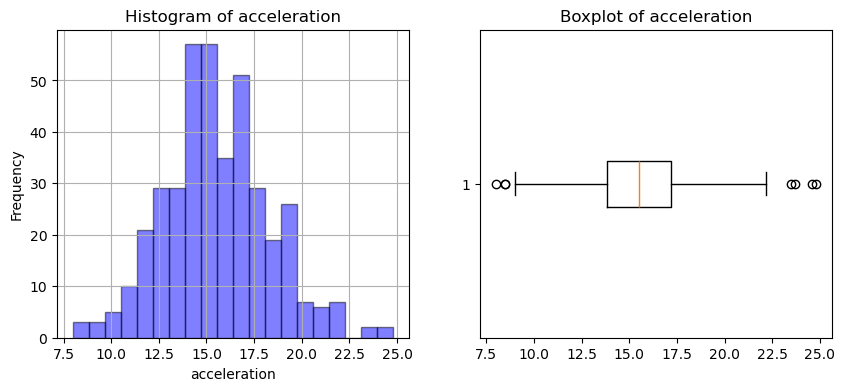

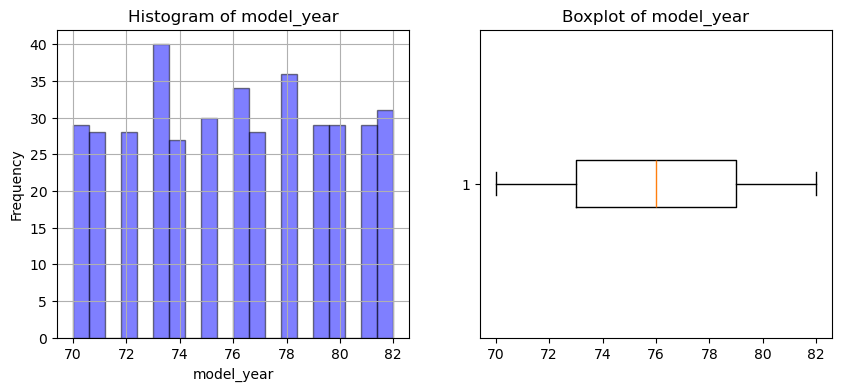

In [95]:
for i in numerical: 
    plt.figure(figsize=(10,4)) 
    plt.subplot(1, 2, 1) 
    df[i].hist(bins=20, alpha=0.5, color='b',edgecolor='black') 
    plt.title(f'Histogram of {i}') 
    plt.xlabel(i) 
    plt.ylabel('Frequency') 
    plt.subplot(1, 2, 2) 
    plt.boxplot(df[i], vert=False) 
    plt.title(f'Boxplot of {i}') 
    plt.show() 

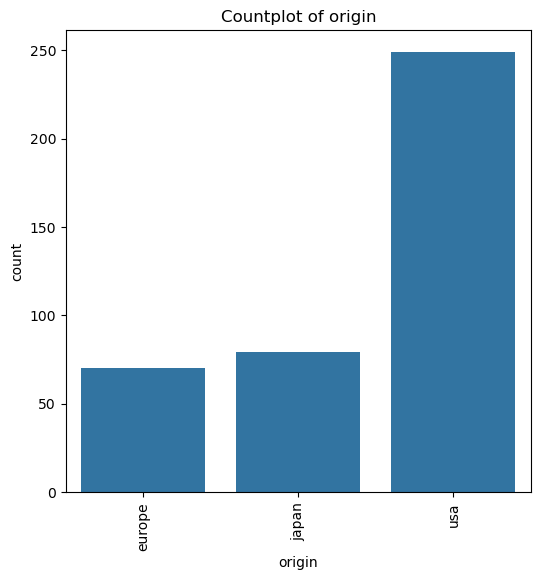

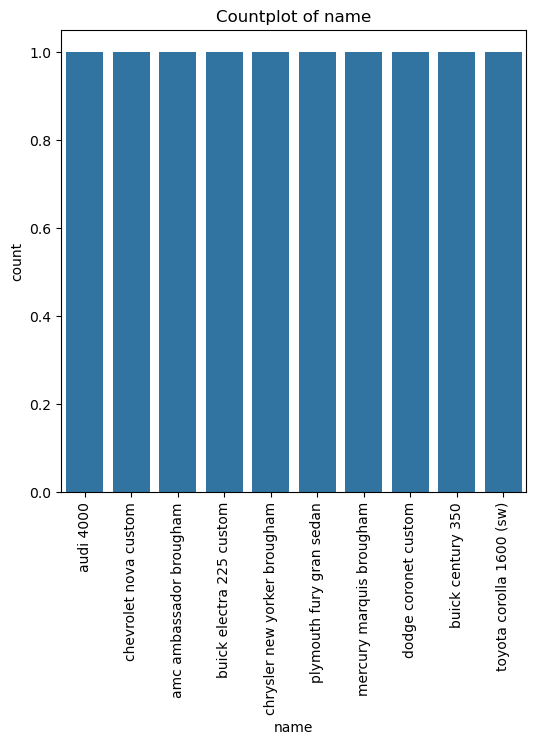

In [96]:

for col in categorical: 
    plt.figure(figsize=(6, 6)) 
    sns.countplot(x=col, data=df, order=df[col].value_counts().sort_values().head(10).index)
    plt.title(f'Countplot of {col}') 
    plt.xticks(rotation=90) 
    plt.show() 

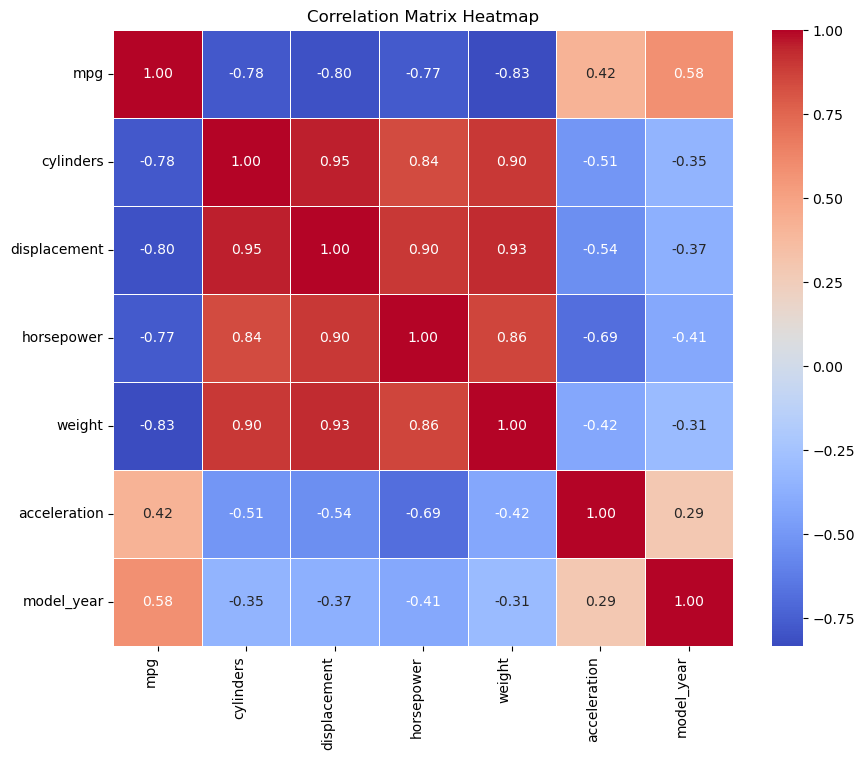

In [97]:

corr_data = df[numerical].corr(method='pearson') 
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) 
plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0) 
plt.title("Correlation Matrix Heatmap") 
plt.show() 

In [98]:
X = df[['horsepower']]
y = df['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
degree = 2 
poly = PolynomialFeatures(degree) 
X_poly_train = poly.fit_transform(X_train) 

In [99]:
model = LinearRegression()
model.fit(X_poly_train, y_train)

LinearRegression()

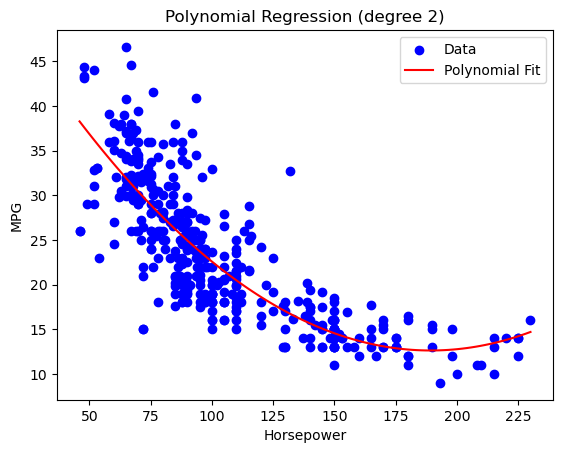

In [100]:
X_poly_test = poly.transform(X_test)
y_pred = model.predict(X_poly_test)

plt.scatter(X, y, color='blue', label='Data')
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)
plt.plot(X_range, y_range_pred, color='red', label='Polynomial Fit')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.title(f'Polynomial Regression (degree {degree})')
plt.show()

In [101]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [102]:
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Mean Squared Error (MSE): 13.94
Root Mean Squared Error (RMSE): 3.73
R-squared (R²): 0.74
